C:\Users\ahmad\AppData\Local\Temp\ipykernel_19736\1345597134.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


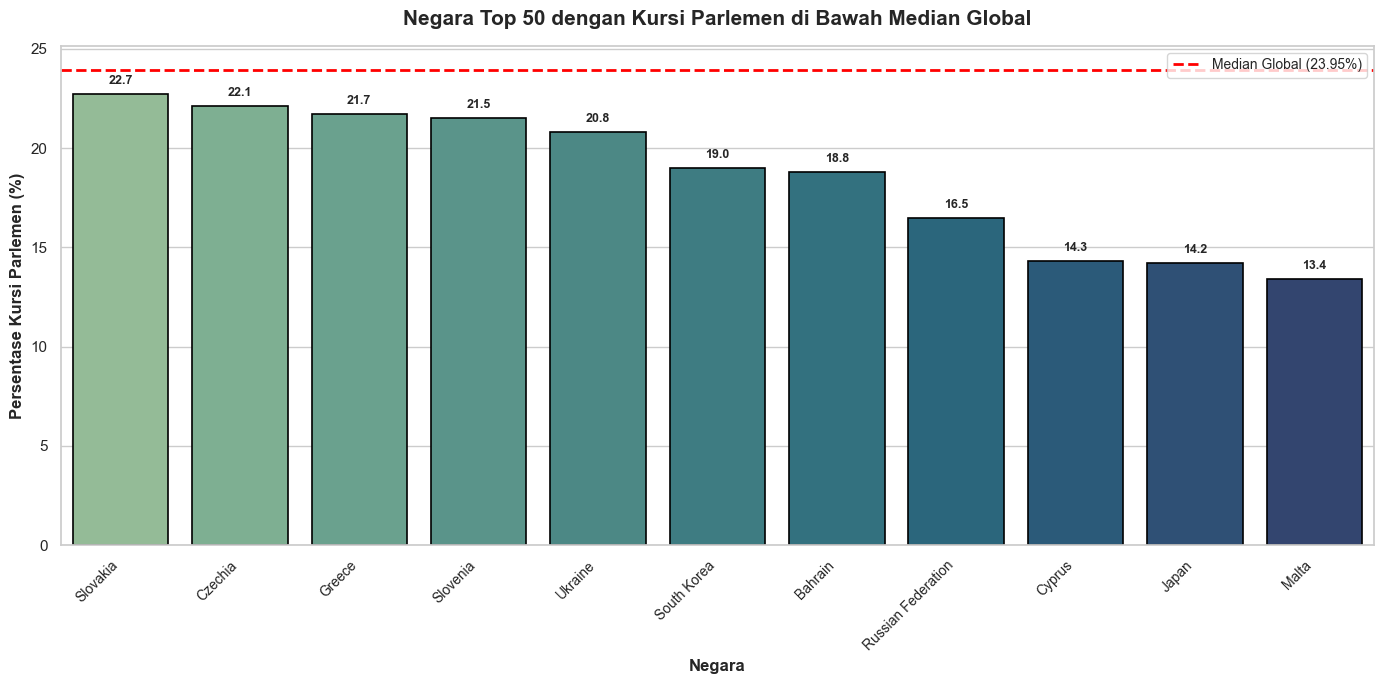

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Konfigurasi visualisasi
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# Membaca dan memfilter data
df = pd.read_csv('Kelas A_Gender Inequality Index.csv')
df_clean = df.dropna(subset=['Country', 'Rank', 'Seats_parliament'])

# Menghitung median global dan seleksi kondisi
median_global = df_clean['Seats_parliament'].median()
df_filtered = df_clean[(df_clean['Rank'] <= 50) & (df_clean['Seats_parliament'] < median_global)]
df_filtered = df_filtered.sort_values(by='Seats_parliament', ascending=False)

# Membuat bar chart
ax = sns.barplot(
    x='Country', 
    y='Seats_parliament', 
    data=df_filtered, 
    palette='crest',
    edgecolor='black',
    linewidth=1.2
)

# Menambahkan garis batas (threshold) median global
plt.axhline(median_global, color='red', linestyle='--', linewidth=2, label=f'Median Global ({median_global:.2f}%)')
plt.legend(loc='upper right', fontsize=10)

# Kustomisasi label sumbu
plt.title('Negara Top 50 dengan Kursi Parlemen di Bawah Median Global', 
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Negara', fontsize=12, fontweight='bold')
plt.ylabel('Persentase Kursi Parlemen (%)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)

# Menambahkan anotasi nilai pada bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                xytext=(0, 5), textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.tight_layout()
# Menyimpan grafik sesuai penamaan soal
plt.savefig('Soal_2_Top_50_Kursi_Parlemen.png', dpi=300, bbox_inches='tight')